#### Setting up the environment
The first step is to set up the conda environment. You should use the `profsea-env.yml` environment file, building it with 

```bash
conda env create -f profsea-env.yml
```

and then activating with `conda activate profsea`.

---

One final step here is to install ProFSea as an editable package, using

```bash 
pip install -e . 
```

while inside the highest level directory.

#### Importing components

The next step is to import all the model components you want to run simulations with - a full list is available in the documention [here](). This can be any combination of available `global` and `spatial` components, how you build your model is up to you!

To generate a comprehensive set of sea-level projections, we'll run with all the components that contribute to sea-level change: 
- thermal expansion
- glaciers
- greenland ice-sheet
- antarctic ice-sheet
- landwater 

In the example below, we'll run with the configuration being used for SLEIP and Munday et al. (2026), *in prep*.

In [1]:
from profsea.components.core.global_model import Global
from profsea.components.global_ import (
    LandwaterAR6,
    GreenlandAR6,
    ThermalExpansion,
    AntarcticaISMIP6,
    Glacier,
)

`ProFSea` can run with a single or an ensemble of temperature and ocean heat content forcing trajectories. The trajectories need to be anomalies, relative to some baseline period - `ProFSea` assumes by default this is `1996-2014`

Here we'll just run with an idealised temperature ramp up and stabilisation, and corresponding ocean heat content change, running from `2006` to `2300`:

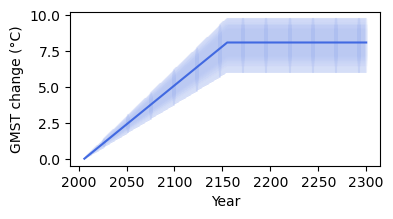

In [2]:
import matplotlib.pyplot as plt
import numpy as np

t_change = np.concatenate(
    [np.linspace(0.01, 8, 150), np.linspace(8, 8, 145)]
)
t_change = t_change[None, :] * np.random.normal(loc=1.0, scale=0.1, size=(100, 1)) # add some variability across members
ohc_change = t_change * 1e24 # in Joules
years = np.arange(2006, 2301)
years = np.broadcast_to(years, t_change.shape)

plt.figure(figsize=(4, 2))
plt.plot(years, t_change, color="royalblue", alpha=0.1)
plt.plot(years.mean(axis=0), t_change.mean(axis=0), color="royalblue", label="GMST change")
plt.xlabel("Year")
plt.ylabel("GMST change (°C)")
plt.show()
plt.close()

#### Building the model

To build your model, simply add your components to a dictionary, with whatever names you like, and pass it to the `Global()` class

In [3]:
global_components = {
    "landwater": LandwaterAR6(),
    "greenland": GreenlandAR6(),
    "expansion": ThermalExpansion(ohc_change), # only the thermal expansion needs OHC change, so we'll pass it in here
    "wais": AntarcticaISMIP6(ais_region="wais"),
    "eais": AntarcticaISMIP6(ais_region="eais"),
    "peninsula": AntarcticaISMIP6(ais_region="peninsula"),
    "glacier": Glacier(),
}
global_model = Global(components=global_components, end_yr=2301, num_members=1000)

now we're ready to run our simulation...

In [4]:
projections = global_model.run(
    T_change=t_change,
    scenario="stabilisation",
    member_seed=42
)
global_model.sum_components(projections)
gmslr = global_model.results["gmslr"]

visualise the global simulations!

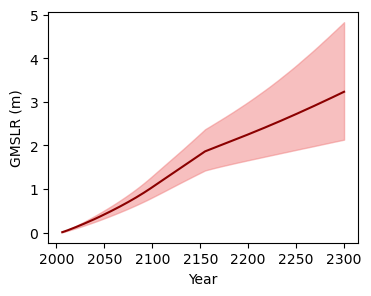

In [5]:
plt.figure(figsize=(4, 3))
lower = np.percentile(gmslr, 5, axis=0)
upper = np.percentile(gmslr, 95, axis=0)
plt.fill_between(years[0], lower, upper, color="lightcoral", alpha=0.5, label="90% range")
plt.plot(years[0], gmslr.mean(axis=0), color="darkred")
plt.xlabel("Year")
plt.ylabel("GMSLR (m)")
plt.show()
plt.close()

#### Building the `Spatial` model

Start with the imports:

In [7]:
from profsea.components.core import Spatial
from profsea.components.spatial import (
    SterodynamicCMIP6,
    Fingerprint,
    GIA,
)

Now we'll build the model in the same way as the global model, but we'll pass the individual components' global projections to each spatial module. 

In [24]:
spatial_components = {
    "sterodynamic": SterodynamicCMIP6(
        projections["expansion"], # passing in the global thermal expansion projection
    ),
    "greenland": Fingerprint(
        projections["greenland"], fingerprint_component="greenland"
    ),
    "landwater": Fingerprint(
        projections["landwater"],
        fingerprint_component="landwater",
    ),
    "wais": Fingerprint(
        projections["wais"],
        fingerprint_component="wais",
    ),
    "eais": Fingerprint(
        projections["eais"],
        fingerprint_component="eais",
    ),
    "glacier": Fingerprint(
        projections["glacier"],
        fingerprint_component="glacier",
    ),
    "gia": GIA(
        sample_spatial=False,
    ),
}

# Pass to the spatial model
spatial_model = Spatial(components=spatial_components)
spatial_model.run(member_seed=42)

total_rsl = spatial_model.sum_components(spatial_model.results)

[22:56:08] ✓ ProFSea assets found locally!                                                             ]8;id=6536702;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py\utils.py]8;;\:]8;id=6536703;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py#115\115]8;;\

[22:56:08] Baseline period = 1995 to 2014                                                       ]8;id=6536710;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/spatial_model.py\spatial_model.py]8;;\:]8;id=6536711;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/spatial_model.py#98\98]8;;\

           Simulating 7 sea-level components...: sterodynamic, greenland, landwater, wais,     ]8;id=6536717;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/spatial_model.py\spatial_model.py]8;;\:]8;id=6536718;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/spatial_model.py#179\179]8;;\
           eais, glacier, gia                                                                                      

Output()

Saving the spatial projections is easy + quick using Zarr format: 

In [9]:
spatial_model.save_components(
    spatial_model.results, scenario_name="stabilisation", output_format="zarr"
)

/Users/gregorymunday/anaconda3/envs/profsea/lib/python3.12/site-packages/zarr/co
re/group.py:2662: ZarrUserWarning: The `compressor` argument is deprecated. Use 
`compressors` instead.
  compressors = _parse_deprecated_compressor(
/Users/gregorymunday/anaconda3/envs/profsea/lib/python3.12/site-packages/zarr/ap
i/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not 
part in the Zarr format 3 specification. It may not be supported by other zarr 
implementations and may change in the future.
  warnings.warn(
⠸ Streaming computation and saving Zarr...
[15:28:57] ✓ Successfully saved Zarr:                       ]8;id=625604;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/spatial_model.py\spatial_model.py]8;;\:]8;id=625605;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/spatial_model.py#319\319]8;;\
           ./stabilisation_spatial_projection.zarr                             

Plot the output! This takes about 90 seconds, since our data goes from lazy &rarr; in memory

In [53]:
# Add a land-sea mask to results.total_rsl (set vals to NaN over land) 
# Mask is in here: profsea/profsea-assets/cmip6-patterns/ACCESS-CM2/zos_mask_ssp245_ACCESS-CM2.nc
import xarray as xr
mask = xr.open_dataset("../../profsea/profsea-assets/cmip6-patterns/ACCESS-CM2/zos_mask_ssp245_ACCESS-CM2.nc").zos_mask
total_rsl_masked = total_rsl.where(mask == 0)

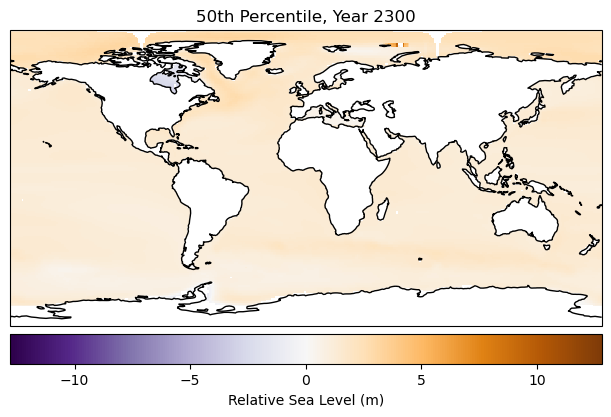

In [55]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(6, 4), layout="constrained")

total_rsl_med = total_rsl_masked[2, -1, :, :]
vmax = np.nanmax(np.abs(total_rsl))
vmin = -vmax

ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.set_title("50th Percentile, Year 2300")
ax.pcolormesh(
    spatial_model.grid_lons,
    spatial_model.grid_lats,
    total_rsl_med,
    transform=ccrs.PlateCarree(),
    cmap="PuOr_r",
    vmin=vmin,
    vmax=vmax,
)
ax.coastlines()
fig.colorbar(
    mappable=ax.collections[0],
    label="Relative Sea Level (m)",
    orientation="horizontal",
    pad=0.02,
)
plt.show()

Next, we'll drill down on a few grid-boxes of interest. To do this we can use the `Local` model.

We give the spatial components to our `Local` model, and a dictionary of locations with associated lat/lons: 

In [6]:
from profsea.components.core.local_model import Local

from profsea.components.core import Spatial
from profsea.components.spatial import (
    SterodynamicCMIP6,
    Fingerprint,
    GIA,
)

locations = {
    "Aberdeen": (57.144, -2.080),
    "Holyhead": (53.314, -4.620),
    "Llandudno": (53.330, -3.830),
}

local_components = {
    "sterodynamic": SterodynamicCMIP6(
        projections["expansion"],  # passing in the global thermal expansion projection
    ),
    "greenland": Fingerprint(
        projections["greenland"], 
        fingerprint_component="greenland"
    ),
    "landwater": Fingerprint(
        projections["landwater"],
        fingerprint_component="landwater",
    ),
    "wais": Fingerprint(
        projections["wais"],
        fingerprint_component="wais",
    ),
    "eais": Fingerprint(
        projections["eais"],
        fingerprint_component="eais",
    ),
    "glacier": Fingerprint(
        projections["glacier"],
        fingerprint_component="glacier",
    ),
    "gia": GIA(
        sample_spatial=False,
    ),
}

local_model = Local(components=local_components, locations=locations)
local_timeseries = local_model.run(member_seed=42)

[23:54:17] ✓ ProFSea assets found locally!                                                             ]8;id=14796535;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py\utils.py]8;;\:]8;id=14796536;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/utils/utils.py#117\117]8;;\

[23:54:17] Baseline period = 1995 to 2014                                                         ]8;id=14796543;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/local_model.py\local_model.py]8;;\:]8;id=14796544;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/local_model.py#79\79]8;;\

           Configured for 3 specific target locations.                                            ]8;id=14796550;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/local_model.py\local_model.py]8;;\:]8;id=14796551;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/local_model.py#82\82]8;;\

           Simulating 7 sea-level components for 3 sites...                                      ]8;id=14796557;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/local_model.py\local_model.py]8;;\:]8;id=14796558;file:///Users/gregorymunday/Documents/Papers/ProFSea/ProFSea-tool/profsea/components/core/local_model.py#117\117]8;;\

Output()

Text(0, 0.5, 'Relative Sea Level (m)')

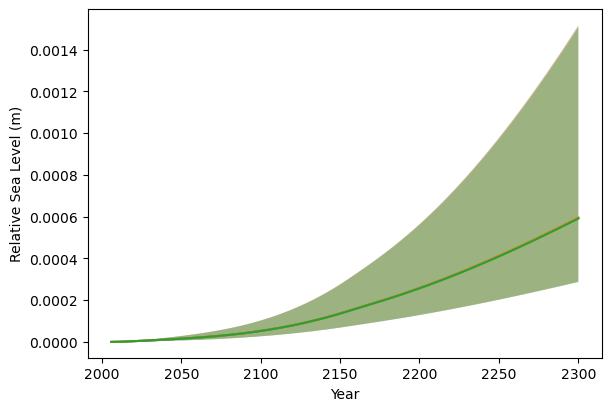

In [8]:
loc_ts = local_timeseries["wais"].sel(site=["Aberdeen", "Holyhead", "Llandudno"], percentile=[17, 50, 83])
fig = plt.figure(figsize=(6, 4), layout="constrained")
ax = fig.add_subplot(111)
for loc in loc_ts.site.values:
    loc_data = loc_ts.sel(site=loc)
    ax.fill_between(loc_data.time, loc_data.sel(percentile=17), loc_data.sel(percentile=83), alpha=0.3, label=f"{loc} 66% range")
    ax.plot(loc_data.time, loc_data.sel(percentile=50), label=loc)
ax.set_xlabel("Year")
ax.set_ylabel("Relative Sea Level (m)")